In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/PaddleDet-Models

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/My Drive/PaddleDet-Models


In [3]:
!python --version

Python 3.12.13


In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/sispanseg/train/images")
count_images("datasets/sispanseg/valid/images")

Total images: 200
Total images: 56


In [ ]:
# Check train annotations
with open("datasets/sispanseg/train/instances_train_polygon.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("datasets/sispanseg/valid/instances_val_polygon.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 200
Train annotations: 296
Categories: [{'id': 1, 'name': 'Grasper', 'isthing': 1}, {'id': 2, 'name': 'Harmonic ACE', 'isthing': 1}, {'id': 3, 'name': 'Myoma Screw', 'isthing': 1}, {'id': 4, 'name': 'Needle Holder', 'isthing': 1}, {'id': 5, 'name': 'Trocer', 'isthing': 1}]

Valid images: 56
Valid annotations: 89


In [2]:
!git clone https://github.com/PaddlePaddle/PaddleDetection.git
%cd PaddleDetection

fatal: destination path 'PaddleDetection' already exists and is not an empty directory.
/content/gdrive/My Drive/PaddleDet-Models/PaddleDetection


In [5]:
!pip install paddlepaddle-gpu pyclipper attrdict gdown -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.9/758.9 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 45.8 MB/s eta 0:00:00


In [ ]:
# Force the "bridge" version of NumPy that works for both Python 3.12 and Paddle
!pip install numpy==1.26.4 --force-reinstall

# Re-install OpenCV without dependencies to stop it from fighting with NumPy
!pip install opencv-python-headless --no-deps --force-reinstall

In [3]:
!pip install -q -e .

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.5/443.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.0/417.0 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 25.0 MB/s eta 0:00:00


In [4]:
!python -c "import paddle; print(paddle.__version__); print(paddle.device.get_device()); import ppdet; print(ppdet.__version__)"

2.6.2
gpu:0
[05/21 06:20:12] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
0.0.0


In [5]:
!python ppdet/modeling/tests/test_architectures.py

[05/21 06:21:13] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0521 06:21:15.947057  3829 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0521 06:21:15.969695  3829 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
.......
----------------------------------------------------------------------
Ran 7 tests in 11.555s

OK


In [6]:
import json
import os

os.makedirs('dataset/coco/annotations', exist_ok=True)

COCO_CLASSES = ('person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
                'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
                'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog',
                'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
                'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
                'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
                'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
                'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
                'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
                'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
                'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop',
                'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven',
                'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
                'scissors', 'teddy bear', 'hair drier', 'toothbrush')

categories = []
for i, name in enumerate(COCO_CLASSES):
    categories.append({"id": i, "name": name, "supercategory": "none"})

dummy_data = {
    "images": [],
    "annotations": [],
    "categories": categories
}

with open('dataset/coco/annotations/instances_val2017.json', 'w') as f:
    json.dump(dummy_data, f)

print("Better dummy JSON created! Labels will now show real names.")

Better dummy JSON created! Labels will now show real names.


In [7]:
# !python tools/infer.py --help

In [8]:
!python tools/infer.py \
-c configs/yolox/yolox_m_300e_coco.yml \
-o use_gpu=True \
weights=https://paddledet.bj.bcebos.com/models/yolox_m_300e_coco.pdparams \
--infer_img=/content/gdrive/MyDrive/PaddleDet-Models/datasets/panoptic-tests/room1.png \
--draw_threshold=0.3

[05/21 06:27:25] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0521 06:27:27.956621  5381 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0521 06:27:27.957525  5381 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/21 06:27:28] ppdet.utils.download INFO: Downloading yolox_m_300e_coco.pdparams from https://paddledet.bj.bcebos.com/models/yolox_m_300e_coco.pdparams
100% 99156/99156 [00:25<00:00, 3931.61KB/s] 
[05/21 06:27:56] ppdet.utils.checkpoint INFO: Finish loading model weights: /root/.cache/paddle/weights/yolox_m_300e_coco.pdparams
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
100% 1/1 [00:02<00:00,  2.27s/it]
[05/21 06:28:00] ppdet.engine INFO: Detection bbox results save in output/room1.png


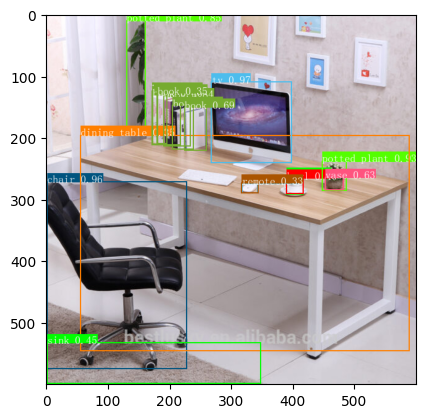

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('output/room1.png')

plt.figure("Image")
plt.imshow(img)
plt.show()

In [20]:
!ls configs/yolox/

_base_			      yolox_nano_300e_coco.yml
README.md		      yolox_s_300e_coco.yml
yolox_cdn_tiny_300e_coco.yml  yolox_sis.yml
yolox_crn_s_300e_coco.yml     yolox_tiny_300e_coco.yml
yolox_l_300e_coco.yml	      yolox_x_300e_coco.yml
yolox_m_300e_coco.yml


In [13]:
200/4

50.0

In [33]:
custom_cfg = """
metric: COCO
num_classes: 5

TrainDataset:
  !COCODataSet
    image_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train/images/
    anno_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train/instances_train_polygon.json
    dataset_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/
    data_fields: ['image', 'gt_bbox', 'gt_class', 'is_crowd']

EvalDataset:
  !COCODataSet
    image_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images/
    anno_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/instances_val_polygon.json
    dataset_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/

TestDataset:
  !ImageFolder
    anno_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/instances_val_polygon.json
    dataset_dir: /content/gdrive/MyDrive/Pytorch-Models/datasets/

worker_num: 4
TrainReader:
  sample_transforms:
    - Decode: {}
    - Mosaic:
        prob: 1.0
        input_dim: [640, 640]
        degrees: [-10, 10]
        scale: [0.1, 2.0]
        shear: [-2, 2]
        translate: [-0.1, 0.1]
        enable_mixup: True
        mixup_prob: 1.0
        mixup_scale: [0.5, 1.5]
    - AugmentHSV: {is_bgr: False, hgain: 5, sgain: 30, vgain: 30}
    - PadResize: {target_size: 640}
    - RandomFlip: {}
  batch_transforms:
    - Permute: {}
  batch_size: 4
  shuffle: True
  drop_last: True
  collate_batch: False
  mosaic_epoch: 10

EvalReader:
  sample_transforms:
    - Decode: {}
    - Resize: {target_size: [640, 640], keep_ratio: True, interp: 1}
    - Pad: {size: [640, 640], fill_value: [114., 114., 114.]}
    - Permute: {}
  batch_size: 2

TestReader:
  inputs_def:
    image_shape: [3, 640, 640]
  sample_transforms:
    - Decode: {}
    - Resize: {target_size: [640, 640], keep_ratio: True, interp: 1}
    - Pad: {size: [640, 640], fill_value: [114., 114., 114.]}
    - Permute: {}
  batch_size: 2

architecture: YOLOX
pretrain_weights: https://paddledet.bj.bcebos.com/models/yolox_m_300e_coco.pdparams
norm_type: sync_bn
use_ema: True
ema_decay: 0.9999
ema_decay_type: "exponential"
act: silu
find_unused_parameters: True

depth_mult: 0.67
width_mult: 0.75

YOLOX:
  backbone: CSPDarkNet
  neck: YOLOCSPPAN
  head: YOLOXHead
  size_stride: 32
  size_range: [15, 25] # multi-scale range [480*480 ~ 800*800]

CSPDarkNet:
  arch: "X"
  return_idx: [2, 3, 4]
  depthwise: False

YOLOCSPPAN:
  depthwise: False

YOLOXHead:
  l1_epoch: 10
  depthwise: False
  loss_weight: {cls: 1.0, obj: 1.0, iou: 5.0, l1: 1.0}
  assigner:
    name: SimOTAAssigner
    candidate_topk: 10
    use_vfl: False
  nms:
    name: MultiClassNMS
    nms_top_k: 1000
    keep_top_k: 100
    score_threshold: 0.001
    nms_threshold: 0.65
    # For speed while keep high mAP, you can modify 'nms_top_k' to 1000 and 'keep_top_k' to 100, the mAP will drop about 0.1%.
    # For high speed demo, you can modify 'score_threshold' to 0.25 and 'nms_threshold' to 0.45, but the mAP will drop a lot.

use_gpu: true
use_xpu: false
log_iter: 5
save_dir: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis
snapshot_epoch: 1
print_flops: false

# Exporting the model
export:
  post_process: True  # Whether post-processing is included in the network when export model.
  nms: True           # Whether NMS is included in the network when export model.
  benchmark: False    # It is used to testing model performance, if set `True`, post-process and NMS will not be exported.
  fuse_conv_bn: False

weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/model_final

epoch: 20
LearningRate:
  base_lr: 0.0001
  schedulers:
  - !CosineDecay
    max_epochs: 20
    min_lr_ratio: 0.05
    last_plateau_epochs: 3
  - !ExpWarmup
    epochs: 4

OptimizerBuilder:
  optimizer:
    type: Momentum
    momentum: 0.9
    use_nesterov: True
  regularizer:
    factor: 0.0005
    type: L2
"""

with open('configs/yolox/yolox_sis.yml', 'w') as f:
    f.write(custom_cfg)

In [34]:
# usage: train.py [-h] [-c CONFIG] [-o [OPT ...]] [--eval] [-r RESUME]
#                 [--slim_config SLIM_CONFIG] [--enable_ce ENABLE_CE] [--amp]
#                 [--fleet] [--use_vdl USE_VDL] [--vdl_log_dir VDL_LOG_DIR]
#                 [--use_wandb USE_WANDB] [--save_prediction_only]
#                 [--profiler_options PROFILER_OPTIONS] [--save_proposals]
#                 [--proposals_path PROPOSALS_PATH] [--to_static]

In [35]:
!python tools/train.py \
-c configs/yolox/yolox_sis.yml \
-o use_gpu=True \
--eval

[05/21 07:11:59] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
[05/21 07:11:59] ppdet.data.source.coco INFO: Load [200 samples valid, 0 samples invalid] in file /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train/instances_train_polygon.json.
W0521 07:11:59.776311 25837 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0521 07:11:59.777145 25837 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/21 07:12:01] ppdet.utils.checkpoint INFO: The shape [80] in pretrained weight head.conv_cls.0.2.bias is unmatched with the shape [5] in model head.conv_cls.0.2.bias. And the weight head.conv_cls.0.2.bias will not be loaded
[05/21 07:12:01] ppdet.utils.checkpoint INFO: The shape [80, 192, 1, 1] in pretrained weight head.conv_cls.0.2.weight is unmatched with the shape [5, 192, 1, 1] in model head

In [36]:
!python tools/eval.py \
-c configs/yolox/yolox_sis.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/best_model \
-o use_gpu=True

[05/21 07:33:39] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0521 07:33:39.847956 50195 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0521 07:33:39.849068 50195 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
[05/21 07:33:40] ppdet.data.source.coco INFO: Load [56 samples valid, 0 samples invalid] in file /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/instances_val_polygon.json.
[05/21 07:33:40] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/model_final.pdparams
[05/21 07:33:42] ppdet.engine.callbacks INFO: Eval iter: 0
[05/21 07:33:44] ppdet.metrics.metrics INFO: The bbox result is saved to bbox.json.
loading annotations into memory...
Done (t=0.03s)
creating index...
index creat

In [37]:
!python tools/infer.py \
-c configs/yolox/yolox_sis.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/best_model \
-o use_gpu=True \
--infer_img=/content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images/Laparoscopic-Myomectomy-with-Baseball-Suturing-22-_jpg.rf.04929e16d4ace3507c937c4e1ce8a333.jpg \
--draw_threshold=0.3

[05/21 07:35:52] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0521 07:35:52.849608 50806 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0521 07:35:52.850636 50806 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/21 07:35:54] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/model_final.pdparams
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
100% 1/1 [00:00<00:00,  1.29it/s]
[05/21 07:35:55] ppdet.engine INFO: Detection bbox results save in output/Laparoscopic-Myomectomy-with-Baseball-Suturing-22-_jpg.rf.04929e16d4ace3507c937c4e1ce8a333.jpg


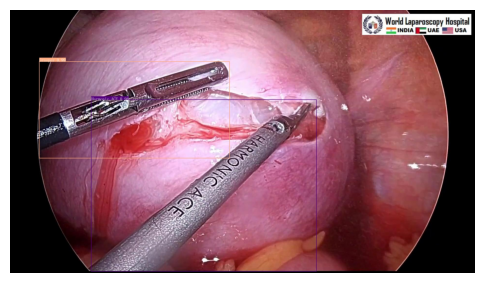

In [39]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('output/Laparoscopic-Myomectomy-with-Baseball-Suturing-22-_jpg.rf.04929e16d4ace3507c937c4e1ce8a333.jpg')

plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img)
plt.show()

In [40]:
!python tools/infer.py \
-c configs/yolox/yolox_sis.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/best_model \
-o use_gpu=True \
--infer_dir=/content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images/ \
--output_dir=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/infer_images/ \
--draw_threshold=0.3 \
--save_results=True

[05/21 07:38:28] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
W0521 07:38:28.229482 51468 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0521 07:38:28.230372 51468 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[05/21 07:38:29] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/model_final.pdparams
[05/21 07:38:29] train INFO: Found 56 inference images in total.
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
100% 28/28 [00:02<00:00,  9.74it/s]
[05/21 07:38:32] ppdet.metrics.metrics INFO: The bbox result is saved to bbox.json.
[05/21 07:38:32] ppdet.metrics.metrics INFO: The bbox result

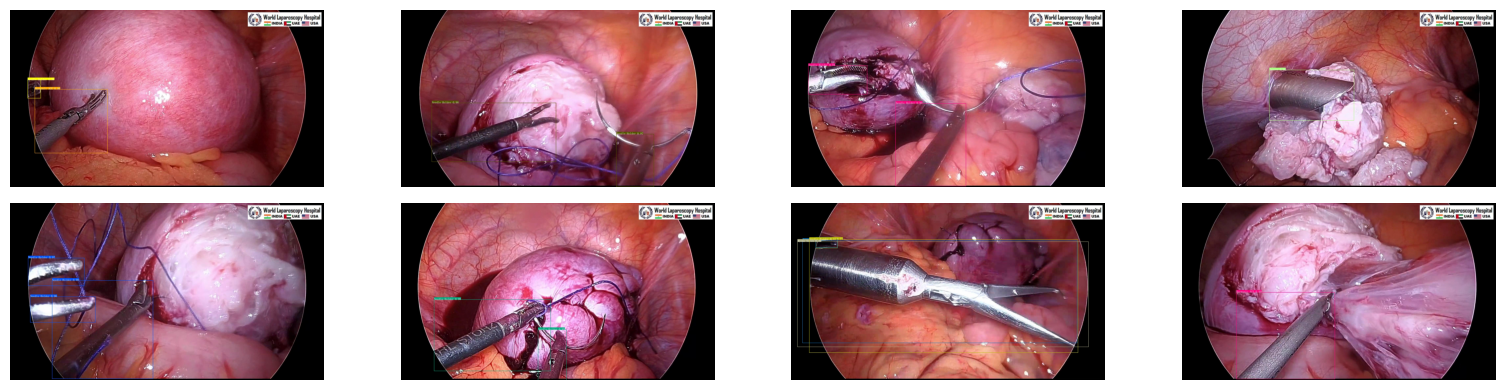

In [42]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import cv2
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/infer_images/"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [43]:
!python tools/export_model.py \
-c configs/yolox/yolox_sis.yml \
-o weights=/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/best_model

[05/21 07:45:54] ppdet.utils.checkpoint INFO: Skipping import of the encryption module.
[05/21 07:45:57] ppdet.utils.checkpoint INFO: Finish loading model weights: /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/best_model.pdparams
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
[05/21 07:46:06] ppdet.engine INFO: Export inference config file to output_inference/yolox_sis/infer_cfg.yml
[05/21 07:46:06] ppdet.engine INFO: Skipping import of the encryption module.
I0521 07:46:06.892323 53346 program_interpreter.cc:212] New Executor is Running.
[05/21 07:46:07] ppdet.engine INFO: Export model and saved in output_inference/yolox_sis


In [44]:
!pip install onnx onnxscript paddle2onnx==1.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.4 MB/s eta 0:00:00


In [45]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 2.4 MB/s eta 0:00:00


In [46]:
!paddle2onnx --model_dir=./output_inference/yolox_sis/ \
            --model_filename model.pdmodel  \
            --params_filename model.pdiparams \
            --opset_version 16 \
            --save_file /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/yolox_sis.onnx

[Paddle2ONNX] Start to parse PaddlePaddle model...
[Paddle2ONNX] Model file path: ./output_inference/yolox_sis/model.pdmodel
[Paddle2ONNX] Paramters file path: ./output_inference/yolox_sis/model.pdiparams
[Paddle2ONNX] Start to parsing Paddle model...
[Paddle2ONNX] Use opset_version = 16 for ONNX export.
[WARN][Paddle2ONNX] [multiclass_nms3: multiclass_nms3_0.tmp_1] [WARNING] Due to the operator multiclass_nms3, the exported ONNX model will only supports inference with input batch_size == 1.
[Paddle2ONNX] PaddlePaddle model is exported as ONNX format now.
2026-05-21 07:48:13 [INFO]	===============Make PaddlePaddle Better!================
2026-05-21 07:48:13 [INFO]	A little survey: https://iwenjuan.baidu.com/?code=r8hu2s


In [48]:
%ls /content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/

best_model/          best_model.pdstates  model_final.pdparams
best_model.pdema     infer_images/        model_final.pdstates
best_model.pdopt     model_final.pdema    yolox_sis.onnx
best_model.pdparams  model_final.pdopt


In [69]:
import onnxruntime
import numpy as np
import cv2
import torch

# Load image and preprocess
img_path = "/content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images/Laparoscopic-Myomectomy-with-Baseball-Suturing-22-_jpg.rf.04929e16d4ace3507c937c4e1ce8a333.jpg"

img = cv2.imread(img_path)
orig_h, orig_w = img.shape[:2] # Get original dimensions
img_resized = cv2.resize(img, (640, 640))
img_input = (img_resized[:, :, ::-1].astype(np.float32))
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Calculate scale factor
# PaddleDetection ONNX models with post-processing often expect scale_factor as [original_height / target_height, original_width / target_width]
scale_y = orig_h / 640.0
scale_x = orig_w / 640.0
scale_factor_input = np.array([[scale_y, scale_x]], dtype=np.float32)

# Calculate im_shape for the model
# Assuming im_shape expects the original image height and width
im_shape_input = np.array([[orig_h, orig_w]], dtype=np.float32)

# Run inference
session = onnxruntime.InferenceSession("/content/gdrive/MyDrive/PaddleDet-Models/PaddleDetection/paddledet-outputs/yolox_sis/yolox_sis.onnx", providers=["CUDAExecutionProvider"])

# Inspect inputs to confirm names and shapes (for debugging)
input_names = [inp.name for inp in session.get_inputs()]
print("Expected input names from ONNX model:", input_names)

# Provide both 'image' and 'scale_factor' as required by the model
input_feed = {
    "image": img_input,
    "scale_factor": scale_factor_input
}

outputs = session.run(None, input_feed)

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Expected input names from ONNX model: ['image', 'scale_factor']
Output: [(100, 6), (1,)]


In [70]:
print(outputs[0])

[[ 1.00000000e+00  9.67502832e-01  3.55723991e+01  1.28330688e+02
   1.41936462e+02  3.61726807e+02]
 [ 0.00000000e+00  9.32503581e-01  1.09614573e+01  7.59350586e+01
   1.00873055e+02  2.07848068e+02]
 [ 3.00000000e+00  3.08462709e-01  1.13308611e+01  7.40556793e+01
   1.01096367e+02  2.06334854e+02]
 [ 2.00000000e+00  1.87115744e-01  1.16280413e+01  7.58475952e+01
   1.00784218e+02  2.08085358e+02]
 [ 1.00000000e+00  1.79855376e-01  1.16280413e+01  7.58475952e+01
   1.00784218e+02  2.08085358e+02]
 [ 4.00000000e+00  1.06209606e-01  1.16280413e+01  7.58475952e+01
   1.00784218e+02  2.08085358e+02]
 [ 0.00000000e+00  9.78857428e-02  3.47846870e+01  1.28418533e+02
   1.45410355e+02  3.65564453e+02]
 [ 3.00000000e+00  9.24263522e-02  3.47846870e+01  1.28418533e+02
   1.45410355e+02  3.65564453e+02]
 [ 4.00000000e+00  5.75428456e-02  3.47846870e+01  1.28418533e+02
   1.45410355e+02  3.65564453e+02]
 [ 2.00000000e+00  5.58693632e-02  3.47846870e+01  1.28418533e+02
   1.45410355e+02  3.6556

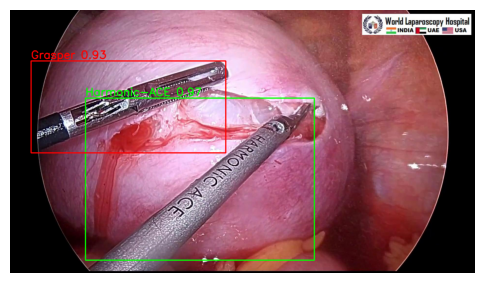

In [74]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

CLASS_LABELS = ["Grasper", "Harmonic-ACE", "Myoma-Screw", "Needle-Holder", "Trocer"]

PRED_COLORS = [
    (0, 0, 255),           # Red - Grasper
    (0, 255, 0),           # Green - Harmonic_Ace
    (255, 0, 0),           # Blue - Myoma_Screw
    (0, 255, 255),         # Yellow - Needle_Holder
    (255, 255, 0)          # Cyan - Trocar
]

# 1. Get original dimensions
orig_h, orig_w = img.shape[:2]
img_with_bbox = img.copy()

# 2. Extract results
# Paddle Output[0] shape is (N, 6) -> [class_id, score, x1, y1, x2, y2]
det_results = outputs[0]

# 3. Filter and Draw
score_thr = 0.5

for res in det_results:
    label_id = int(res[0])
    score = res[1]
    bbox = res[2:] # [x1, y1, x2, y2]

    if score < score_thr:
        continue

    x1, y1, x2, y2 = map(int, bbox)

    # Calculate scale factors
    x1 = int(x1 * orig_w / 640)
    y1 = int(y1 * orig_h / 640)
    x2 = int(x2 * orig_w / 640)
    y2 = int(y2 * orig_h / 640)

    x1 = int(x1 * orig_w / 640)
    y1 = int(y1 * orig_h / 640)
    x2 = int(x2 * orig_w / 640)
    y2 = int(y2 * orig_h / 640)

    label_text = CLASS_LABELS[label_id] if label_id < len(CLASS_LABELS) else f"ID:{label_id}"
    color = PRED_COLORS[label_id]

    # Draw on the ORIGINAL image
    cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), color, 3)
    cv2.putText(img_with_bbox, f"{label_text} {score:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

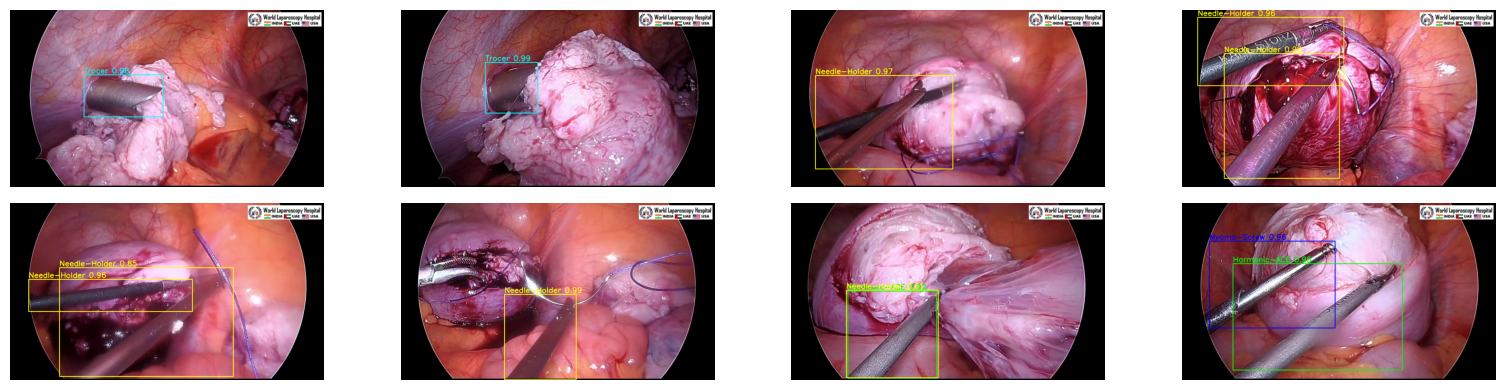

In [78]:
import numpy as np
import os
import random
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images/"

CLASS_LABELS = ["Grasper", "Harmonic-ACE", "Myoma-Screw", "Needle-Holder", "Trocer"]

PRED_COLORS = [
    (0, 0, 255),           # Red - Grasper
    (0, 255, 0),           # Green - Harmonic_Ace
    (255, 0, 0),           # Blue - Myoma_Screw
    (0, 255, 255),         # Yellow - Needle_Holder
    (255, 255, 0)          # Cyan - Trocar
]

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)
    orig_h, orig_w = img.shape[:2]
    img_resized = cv2.resize(img, (640, 640))
    img_input = (img_resized[:, :, ::-1].astype(np.float32))
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    scale_y = orig_h / 640.0
    scale_x = orig_w / 640.0
    scale_factor_input = np.array([[scale_y, scale_x]], dtype=np.float32)

    im_shape_input = np.array([[orig_h, orig_w]], dtype=np.float32)

    input_feed = {
        "image": img_input,
        "scale_factor": scale_factor_input
    }

    outputs = session.run(None, input_feed)

    img_with_bbox = img.copy()
    det_results = outputs[0]

    score_thr = 0.5

    for res in det_results:
        label_id = int(res[0])
        score = res[1]
        bbox = res[2:] # [x1, y1, x2, y2]

        if score < score_thr:
            continue

        x1, y1, x2, y2 = map(int, bbox)

        # Calculate scale factors
        x1 = int(x1 * orig_w / 640)
        y1 = int(y1 * orig_h / 640)
        x2 = int(x2 * orig_w / 640)
        y2 = int(y2 * orig_h / 640)

        x1 = int(x1 * orig_w / 640)
        y1 = int(y1 * orig_h / 640)
        x2 = int(x2 * orig_w / 640)
        y2 = int(y2 * orig_h / 640)

        label_text = CLASS_LABELS[label_id] if label_id < len(CLASS_LABELS) else f"ID:{label_id}"
        color = PRED_COLORS[label_id]

        # Draw on the ORIGINAL image
        cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), color, 3)
        cv2.putText(img_with_bbox, f"{label_text} {score:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, color, 3)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()